In [1]:
# 环境与依赖导入
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
from collections import Counter
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from wordcloud import WordCloud
import warnings
warnings.filterwarnings('ignore')

# 解决中文显示问题
matplotlib.rcParams["font.family"] = "SimHei"
matplotlib.rcParams["axes.unicode_minus"] = False

# 文件路径配置
INPUT_FILE = "../../2.预处理/飞驰人生3_cleaned.csv"
FONT_PATH  = "C:/Windows/Fonts/simhei.ttf"
RANDOM_STATE = 42

# 三类颜色方案
TYPE_META = {
    1:  {"label": "好评", "color": "#2ECC71", "cmap": "Greens"},
    0:  {"label": "中评", "color": "#F39C12", "cmap": "Oranges"},
    -1: {"label": "差评", "color": "#E74C3C", "cmap": "Reds"},
}

type_order = [1, 0, -1]
type_labels = [TYPE_META[t]["label"] for t in type_order]
type_colors_list = [TYPE_META[t]["color"] for t in type_order]

读取数据，隔离拆分好/差评

In [2]:
df = pd.read_csv(INPUT_FILE, encoding="utf-8-sig")
df["tokens"] = df["tokens"].fillna("")

# 将好评和差评拆分开来，分别建立 DataFrame
df_good = df[df["comment_type"] == 1].copy()
df_bad = df[df["comment_type"] == -1].copy()

print(f"总数据量：{len(df)}")
print(f"好评数据量：{len(df_good)} 条")
print(f"差评数据量：{len(df_bad)} 条")


总数据量：1186
好评数据量：399 条
差评数据量：391 条


## 1. 三类评论词云图

### 1.1 独立词云

分别统计好/中/差三类评论的词频，使用 `generate_from_frequencies` 生成词云，
横向 1×3 排列，配色与情感色调一致（绿 / 橙 / 红）。

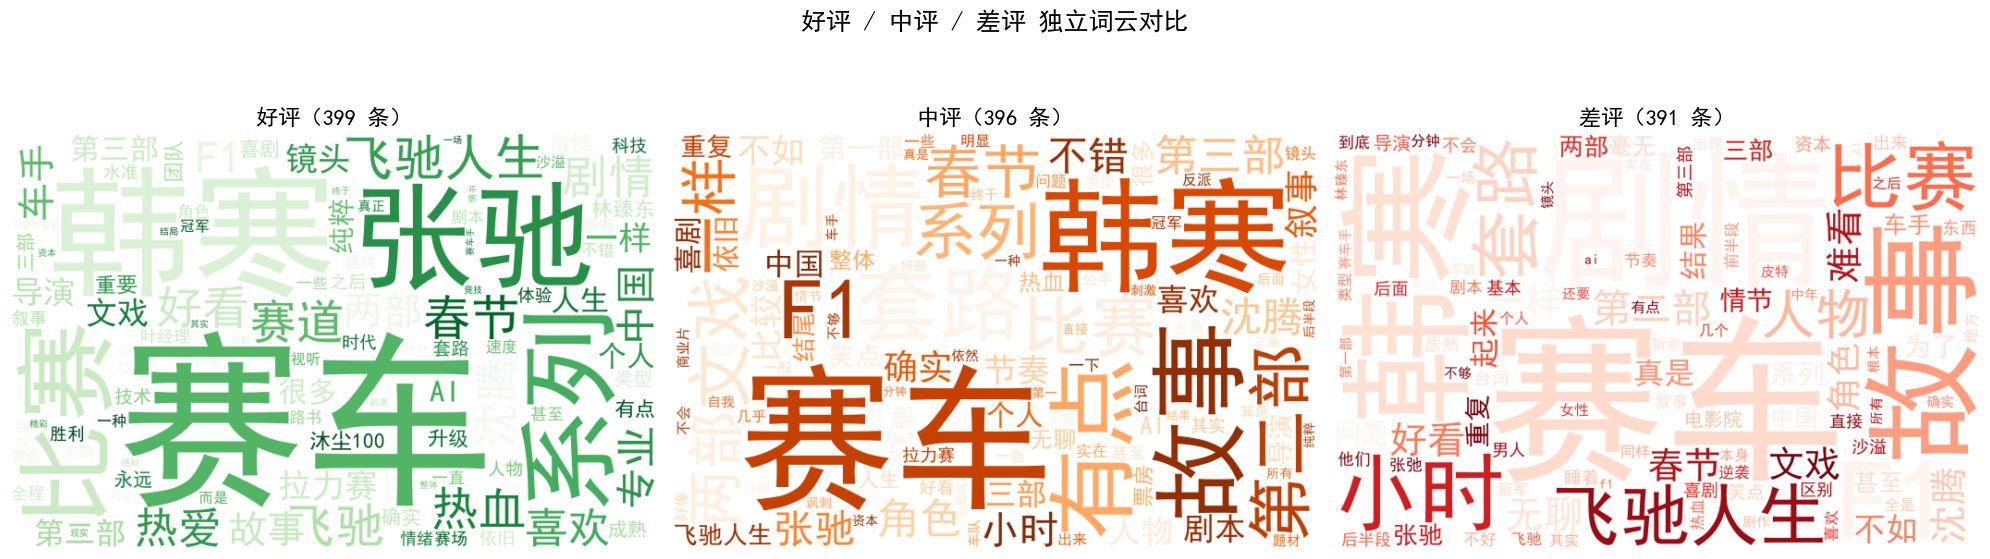

✅ 已保存：词云_三类对比.png


In [3]:
def get_word_freq(token_series):
    """统计分词结果中的词频"""
    all_words = " ".join(token_series).split()
    return Counter(all_words)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for idx, t in enumerate(type_order):
    meta = TYPE_META[t]
    subset = df[df["comment_type"] == t]
    freq = get_word_freq(subset["tokens"])
    wc = WordCloud(
        font_path=FONT_PATH,
        width=700, height=450,
        background_color="white",
        max_words=100,
        colormap=meta["cmap"],
    ).generate_from_frequencies(freq)
    axes[idx].imshow(wc, interpolation="bilinear")
    axes[idx].set_title(f'{meta["label"]}（{len(subset)} 条）',
                        fontsize=16, fontweight="bold")
    axes[idx].axis("off")

plt.suptitle("好评 / 中评 / 差评 独立词云对比", fontsize=18, y=1.02)
plt.tight_layout()
plt.savefig("词云_三类对比.png", dpi=150, bbox_inches="tight")
plt.show()
print("\u2705 已保存：词云_三类对比.png")

### 1.2 特征词词云（去除共有高频词）

对每类评论，用 TF-IDF 提取该类区分度最高的词，
只保留「本类独有」的表达，过滤掉三类共享的通用词。

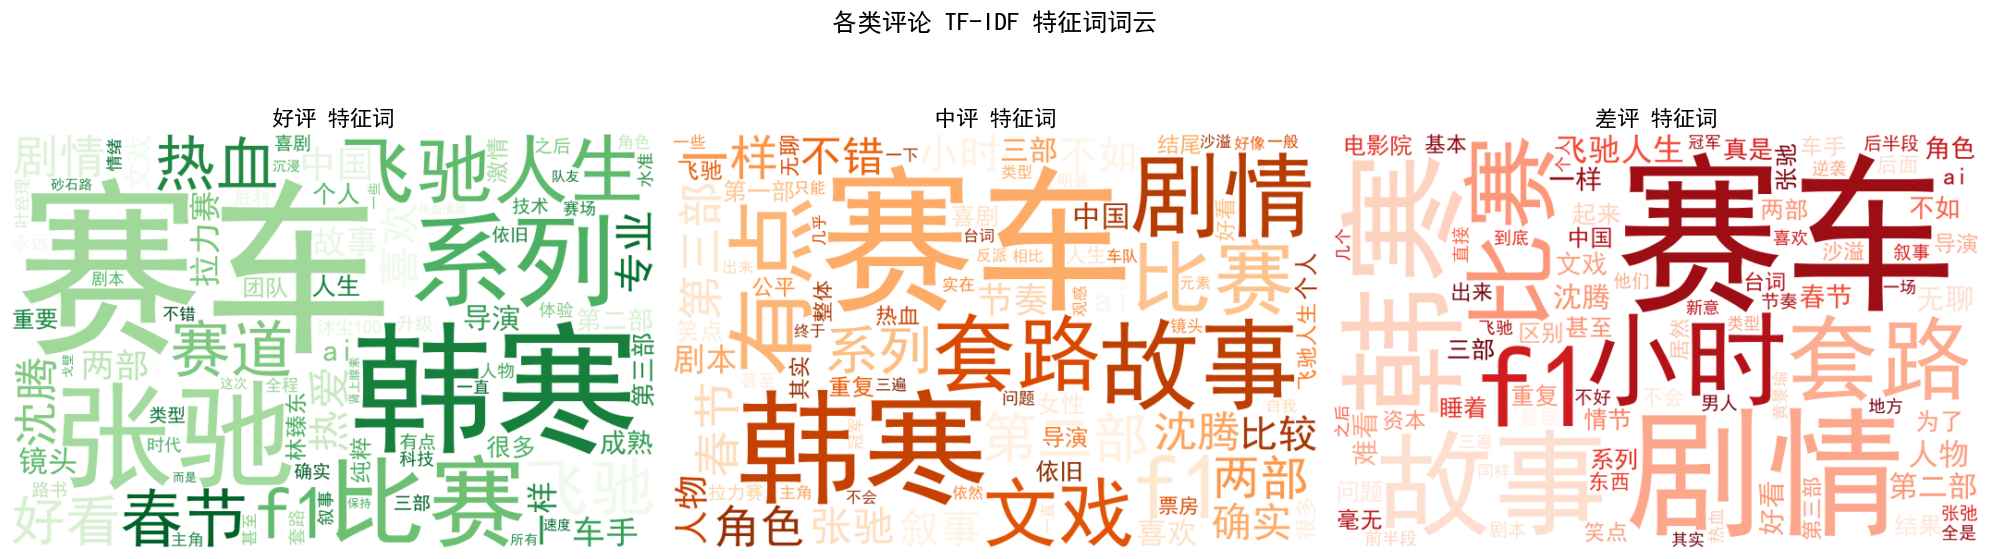

✅ 已保存：词云_特征词对比.png


In [4]:
# 将三类评论各自合并为一篇伪文档；相当于三篇文章
pseudo_docs = []
for t in type_order:
    merged = " ".join(df[df["comment_type"] == t]["tokens"])
    pseudo_docs.append(merged)

tfidf_class = TfidfVectorizer(max_features=500)
X_class = tfidf_class.fit_transform(pseudo_docs)
class_features = tfidf_class.get_feature_names_out()

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for idx, t in enumerate(type_order):
    meta = TYPE_META[t]
    row = X_class[idx].toarray().flatten()
    top_idx = row.argsort()[::-1][:80]
    word_weights = {class_features[j]: row[j] for j in top_idx if row[j] > 0}

    wc = WordCloud(
        font_path=FONT_PATH,
        width=700, height=450,
        background_color="white",
        max_words=80,
        colormap=meta["cmap"],
    ).generate_from_frequencies(word_weights)
    axes[idx].imshow(wc, interpolation="bilinear")
    axes[idx].set_title(f'{meta["label"]} 特征词',
                        fontsize=16, fontweight="bold")
    axes[idx].axis("off")

plt.suptitle("各类评论 TF-IDF 特征词词云", fontsize=18, y=1.02)
plt.tight_layout()
plt.savefig("词云_特征词对比.png", dpi=150, bbox_inches="tight")
plt.show()
print("\u2705 已保存：词云_特征词对比.png")

对每类评论取 TF-IDF 权重最高的 Top 15 词，横向柱状图展示。

这些词是最能代表该类评论、区别于其他类的表达。

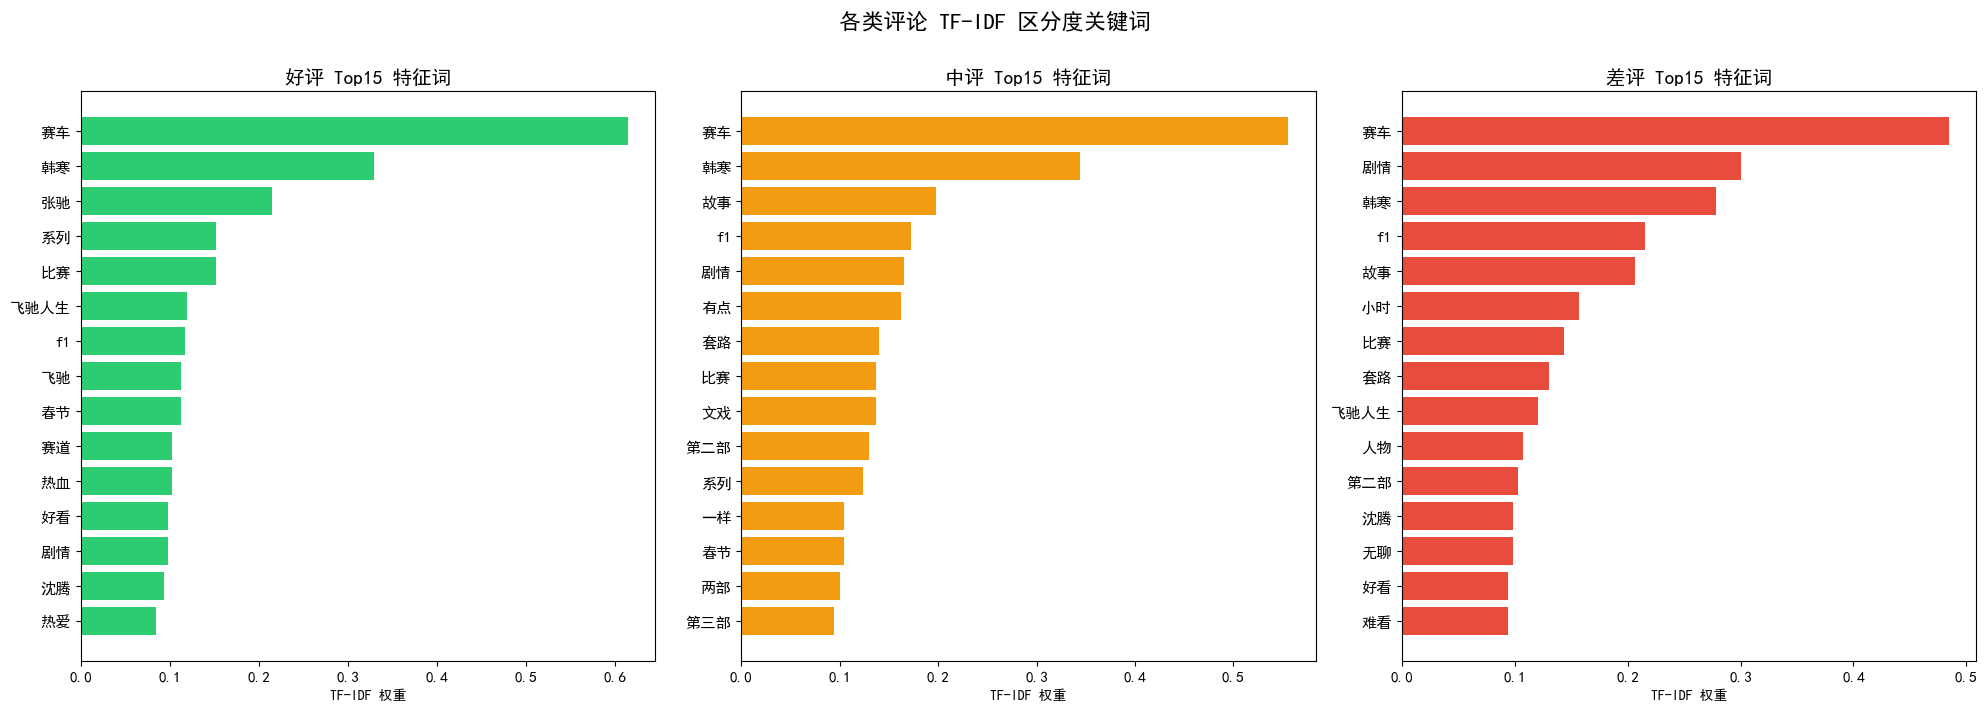

✅ 已保存：TFIDF_区分度关键词.png


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(20, 7))

for idx, t in enumerate(type_order):
    meta = TYPE_META[t]
    row = X_class[idx].toarray().flatten()
    top_idx = row.argsort()[::-1][:15]
    words = [class_features[j] for j in top_idx]
    weights = [row[j] for j in top_idx]

    axes[idx].barh(words[::-1], weights[::-1], color=meta["color"])
    axes[idx].set_title(f'{meta["label"]} Top15 特征词',
                        fontsize=14, fontweight="bold")
    axes[idx].set_xlabel("TF-IDF 权重")
    axes[idx].tick_params(labelsize=11)

plt.suptitle("各类评论 TF-IDF 区分度关键词", fontsize=16, y=1.01)
plt.tight_layout()
plt.savefig("TFIDF_区分度关键词.png", dpi=150, bbox_inches="tight")
plt.show()
print("\u2705 已保存：TFIDF_区分度关键词.png")

## 2. 高频词对比柱状图

取全局 Top 20 高频词，展示同一个词在好/中/差三类中的频率差异。

纵轴已归一化为「每400条评论中的出现次数」，消除各类样本量差异的影响。

可以发现对赛车、张驰好评较多，对剧情、故事差评较多。

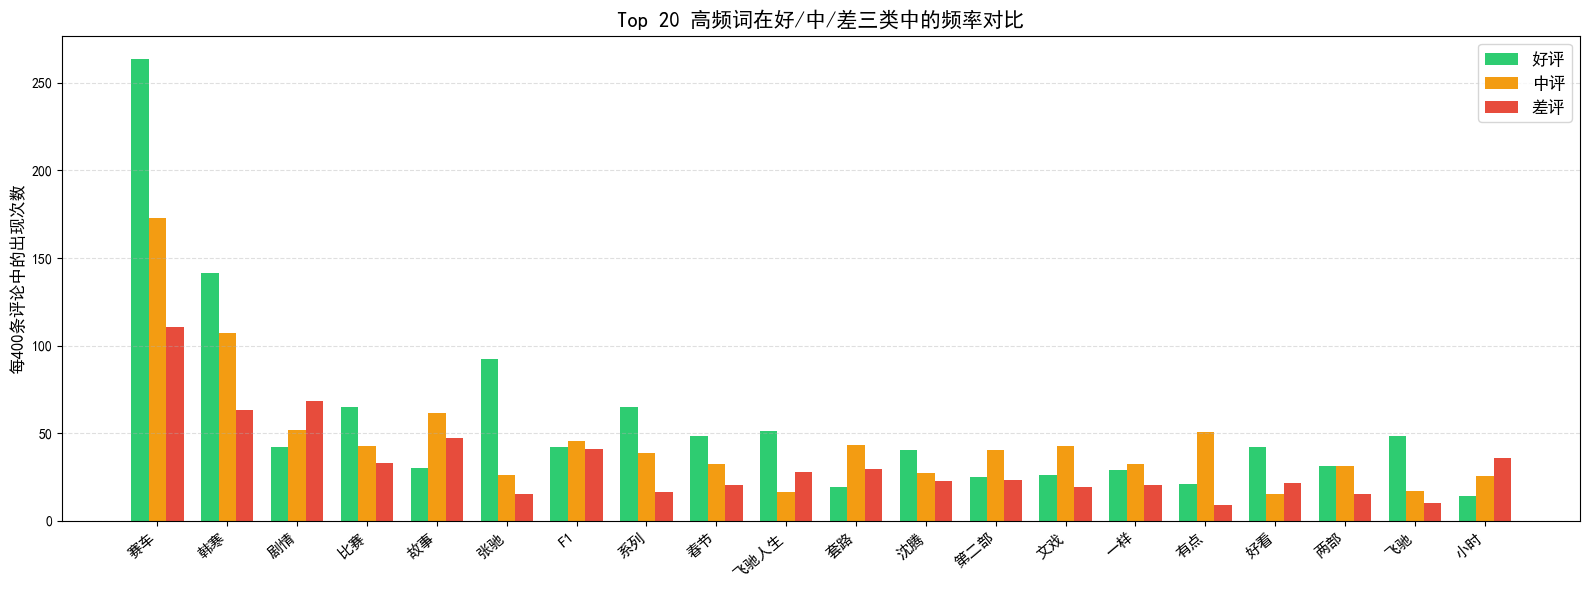

✅ 已保存：高频词_三类对比.png


In [6]:
freq_by_type = {}
for t in type_order:
    freq_by_type[t] = get_word_freq(df[df["comment_type"] == t]["tokens"])

global_freq = get_word_freq(df["tokens"])
top20_words = [w for w, _ in global_freq.most_common(20)]

x = np.arange(len(top20_words))
width = 0.25

fig, ax = plt.subplots(figsize=(16, 6))
for i, t in enumerate(type_order):
    meta = TYPE_META[t]
    n_docs = (df["comment_type"] == t).sum()
    rates = [freq_by_type[t].get(w, 0) / n_docs * 400 for w in top20_words]
    ax.bar(x + i * width, rates, width, label=meta["label"], color=meta["color"])

ax.set_xticks(x + width)
ax.set_xticklabels(top20_words, fontsize=11, rotation=40, ha="right")
ax.set_ylabel("每400条评论中的出现次数", fontsize=12)
ax.set_title("Top 20 高频词在好/中/差三类中的频率对比", fontsize=15)
ax.legend(fontsize=12)
ax.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig("高频词_三类对比.png", dpi=150)
plt.show()
print("\u2705 已保存：高频词_三类对比.png")

### 3. LDA 主题挖掘（分别对好评和差评）

In [7]:
def discover_topics(texts, n_topics=3, n_top_words=10):
    """
    针对输入的文本列表，训练 LDA 主题模型并提取高频特征词
    """
    # 1. 文本向量化 (使用词频，忽略极低频和极高频词)
    tf_vectorizer = CountVectorizer(max_features=800, min_df=3, max_df=0.85)
    tf = tf_vectorizer.fit_transform(texts)
    
    # 2. 训练 LDA 模型
    lda = LatentDirichletAllocation(
        n_components=n_topics, 
        max_iter=20,
        learning_method='online',
        random_state=RANDOM_STATE
    )
    lda.fit(tf)
    
    # 3. 提取并打印每个主题的核心词
    feature_names = tf_vectorizer.get_feature_names_out()
    topics_words = []
    
    print(f"--- 成功提取 {n_topics} 个潜在主题 ---")
    for topic_idx, topic in enumerate(lda.components_):
        top_features_ind = topic.argsort()[:-n_top_words - 1:-1]
        top_features = [feature_names[i] for i in top_features_ind]
        topics_words.append(top_features)
        print(f"主题 #{topic_idx + 1}: {' | '.join(top_features)}")
        
    return tf_vectorizer, tf, lda, topics_words


挖掘好评/差评主题 (好评到底在夸什么？差评到底在骂什么？)

好评：赛车高潮戏的具体细节 (张驰 | 热血 | 赛道 | 选拔 | 路书)

差评：导演前作的“口碑反噬”与预期对比 + 贺岁档的“套路化”与审美疲劳 (无聊 | 难看 | 套路)

In [8]:
print("【好评主题分析】")
# 根据你的好评量，假设提取 3 个主题，每个主题看前 12 个词
good_tf_vectorizer, good_tf, good_lda, good_topics = discover_topics(
    df_good["tokens"], n_topics=3, n_top_words=12
)

print("\n【差评主题分析】")
# 同样提取 3 个主题
bad_tf_vectorizer, bad_tf, bad_lda, bad_topics = discover_topics(
    df_bad["tokens"], n_topics=3, n_top_words=12
)


【好评主题分析】
--- 成功提取 3 个潜在主题 ---
主题 #1: 张驰 | 赛车 | 比赛 | 重要 | 车手 | 导演 | 韩寒 | 选拔 | 飞驰人生 | 人生 | 赛道 | 沐尘100
主题 #2: 赛车 | ai | 韩寒 | 沈腾 | 人类 | 飞驰人生 | f1 | 纯粹 | 好看 | 热血 | 有点 | 不了
主题 #3: 赛车 | 韩寒 | 系列 | 路书 | 文戏 | f1 | 情书 | 梦幻 | 张驰 | 故事 | 一封 | 第二部

【差评主题分析】
--- 成功提取 3 个潜在主题 ---
主题 #1: 赛车 | 小时 | 韩寒 | 无聊 | 难看 | 剧情 | 比赛 | f1 | 一样 | 沈腾 | 真是 | 好看
主题 #2: 不如 | 剧情 | 赛车 | f1 | 套路 | 一般 | 小品 | 四海 | 贺岁片 | 故事 | 第二部 | 人物
主题 #3: 飞驰人生 | 起来 | 角色 | 春节 | 故事 | 飞驰 | 系列 | 区别 | 赛车 | 东西 | 本身 | 老套


使用 pyLDAvis 进行交互式可视化 (以好评为例)

In [9]:
import pyLDAvis
import pyLDAvis.lda_model

pyLDAvis.enable_notebook()

# 可视化好评的主题分布
good_vis = pyLDAvis.lda_model.prepare(good_lda, good_tf, good_tf_vectorizer)
display(good_vis)

# 可以复制这一段代码，将 good 替换为 bad，单独再画一个差评的交互图。


PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
2      0.077449  0.115942       1        1  39.947871
0     -0.149123  0.003032       2        1  38.564790
1      0.071674 -0.118974       3        1  21.487340, topic_info=    Term        Freq       Total Category  logprob  loglift
489   比赛   58.000000   58.000000  Default  30.0000  30.0000
776   韩寒  152.000000  152.000000  Default  29.0000  29.0000
753   重要   33.000000   33.000000  Default  28.0000  28.0000
684   赛车  243.000000  243.000000  Default  27.0000  27.0000
92    人类   15.000000   15.000000  Default  26.0000  26.0000
..   ...         ...         ...      ...      ...      ...
428   春节   10.820320   41.064136   Topic3  -4.8789   0.2040
776   韩寒   15.676410  152.794061   Topic3  -4.5081  -0.7392
438   最佳    6.868484   11.500942   Topic3  -5.3334   1.0222
342   张驰    7.785061   88.292527   Topic3  -5.2081  -0.8907
465  林臻东    6.706080   22.777391   Topic3  -5.3573   0.3150

[202 rows x 6 columns], token_table=      Topic      Freq  Term
term                       
2         1  0.909859    30
4         1  0.376247    ai
4         2  0.086826    ai
4         3  0.520958    ai
6         1  0.611061    f1
...     ...       ...   ...
790       1  0.285259  飞驰人生
790       2  0.427889  飞驰人生
790       3  0.285259  飞驰人生
791       2  0.943601    马年
793       2  0.910765    高效

[257 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[3, 1, 2])

### 4. 结合 votes_count 的平方根加权关键词分析

好评：纯粹的情绪价值（热血：243 / 热爱：210）   硬核的工业质感（赛道：225 / 专业：212）

差评：普遍性的剧本争议（剧情：429 / 故事：158）   续集带来的审美疲劳（重复：264 / 一样：147）

有趣的现象：好评排名高的是 “张驰”  差评排名高的错别字 “张弛” 。（写差评发泄情绪时，往往打字更快，懒得去纠正输入法的默认错别字） 

In [10]:
def get_weighted_top_words(df, top_n=15):
    """计算按获赞数加权后的高频词"""
    weighted_freq = Counter()
    
    for _, row in df.iterrows():
        # 基础权重设为 1，加上点赞数
        weight = int(row.get('votes_count', 0)) + 1 
        tokens = str(row['tokens']).split()
        for word in tokens:
            weighted_freq[word] += weight ** 0.5
            
    return weighted_freq.most_common(top_n)

print("【最具大众共鸣的好评词汇（含点赞加权）】")
for word, score in get_weighted_top_words(df_good, 12):
    print(f"{word}: {score:.2f} 声量")

print("\n【最具大众共鸣的差评词汇（含点赞加权）】")
for word, score in get_weighted_top_words(df_bad, 12):
    print(f"{word}: {score:.2f} 声量")


【最具大众共鸣的好评词汇（含点赞加权）】
赛车: 1320.97 声量
张驰: 667.33 声量
韩寒: 634.69 声量
系列: 356.26 声量
比赛: 342.95 声量
热血: 243.44 声量
AI: 233.57 声量
赛道: 224.92 声量
专业: 212.05 声量
热爱: 209.65 声量
飞驰: 208.79 声量
沈腾: 207.99 声量

【最具大众共鸣的差评词汇（含点赞加权）】
赛车: 460.63 声量
剧情: 429.39 声量
韩寒: 288.91 声量
重复: 264.44 声量
小时: 231.88 声量
张弛: 214.21 声量
F1: 195.67 声量
飞驰人生: 188.20 声量
比赛: 175.81 声量
故事: 158.39 声量
结果: 152.03 声量
一样: 146.69 声量
